# Análisis de Vulnerabilidades y Riesgos en el Ecosistema de HuggingFace

## 1. Contexto y Propósito del Análisis

Hugging Face es una empresa y plataforma de inteligencia artificial fundada en 2016 conocida como el "GitHub de la IA" ya que es un hub centralizado donde investigadores, empresas y desarrolladores pueden compartir, descubrir y colaborar en distintos modelos de machine leraning, datasets y apps de IA. 

Debido al enorme crecimiento en el ecosistema de Inteligencia Artificial y Machine Learning, organizaciones como **Hugging Face** son, a dia de hoy, pilares escenciales de la distribución de modelos y conjuntos de datos. 
Dado que estas herramientas son consumidas masivamente, cualquier vulnerabilidad heredada en ellas representa un riesgo crítico a gran escala.
Por esto este análisis tiene el proposito de evaluar el nivel de riesgo y la postura de seguridad en la cadena de suministro de estas herramientas. 

## 2. Metodología de Extracción
Para lograr este objetivo, se procesaron 25 repositorios de la organización utilizando un *Miner* automatizado compuesto por tres herramientas de escaneo:
* **Syft:** Para la generación de SBOMs.
* **Grype:** Para la detección de vulnerabilidades conocidas en las dependencias.
* **CodeQL:** Para el análisis estático de código fuente.

El resultado de este pipeline nos ha arrojado un dataset estructurado de vulnerabilidades que analizaremos a continuación para caracterizarlas según su tipo, origen y nivel de severidad.

In [4]:
# Importación de Librerías y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import json
import pandas as pd

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de Datos
DATA_PATH = '../data/miner_dataset.json'

if os.path.exists(DATA_PATH):
    try:
        # Cargar el JSON generado por el Miner
        with open(DATA_PATH, 'r') as file:
            raw_data = json.load(file)
        
        if "vulnerabilities" in raw_data:
            df = pd.DataFrame(raw_data["vulnerabilities"])
        else:
            df = pd.DataFrame(raw_data) 
        print(f"Datos cargados exitosamente. Total de vulnerabilidades: {len(df)}")
        
        # Visualizar las primeras filas para verificar correcta carga y estructura de los datos
        display(df.head())
        
    except Exception as e:
        print(f"Ocurrió un error al cargar los datos: {e}")
else:
    print(f"Error: No se encontró el archivo en {DATA_PATH}.")


Datos cargados exitosamente. Total de vulnerabilidades: 754


,vulnerability_id,type,source_tool,repository,location,severity,description,cwe_id,package_name,installed_version,fixed_version,detected_at
0,GHSA-7p94-766c-hgjp,dependency,grype,autotrain-advanced,/requirements.txt,critical,NLTK has a Zip Slip Vulnerability,NaN,nltk,3.9.1,3.9.3,2026-05-02T20:43:21.140538+00:00
1,GHSA-wvwj-cvrp-7pv5,dependency,grype,autotrain-advanced,/requirements.txt,critical,Authlib JWS JWK Header Injection: Signature Ve...,NaN,authlib,1.4.0,1.6.9,2026-05-02T20:43:21.140603+00:00
2,GHSA-3863-2447-669p,dependency,grype,datasets,/setup.py,critical,transformers has a Deserialization of Untruste...,NaN,transformers,4.30.1,4.36.0,2026-05-02T20:43:24.773693+00:00
3,GHSA-53q9-r3pm-6pq6,dependency,grype,datasets,/setup.py,critical,PyTorch: `torch.load` with `weights_only=True`...,NaN,torch,2.0.1,2.6.0,2026-05-02T20:43:24.773677+00:00
4,GHSA-7p94-766c-hgjp,dependency,grype,datatrove,/uv.lock,critical,NLTK has a Zip Slip Vulnerability,NaN,nltk,3.9.1,3.9.3,2026-05-02T20:43:26.459050+00:00


## 3. Análisis de Resultados y Hallazgos Principales

Tras la extracción y carga de los datos extraidos por el Miner, hemos identificado un total de **754 vulnerabilidades** en los 25 repositorios analizados. A partir de la inspección de estos registros, destacan los siguientes hallazgos críticos para el ecosistema de la organización:

In [5]:
# Análisis de Severidad por Herramienta (Tabla Cruzada)

COL_SEVERITY = 'severity'
COL_TOOL = 'source_tool' 

if COL_SEVERITY in df.columns and COL_TOOL in df.columns:
    # pd.crosstab genera la matriz. 'margins=True' añade las filas y columnas de Totales.
    # fillna('Desconocida') asegura que si alguna vulnerabilidad no tiene severidad, no se pierda.
    tabla_severidad_herramienta = pd.crosstab(
        index=df[COL_SEVERITY].fillna('Desconocida'), 
        columns=df[COL_TOOL], 
        margins=True, 
        margins_name='Total General'
    )
    
    print("Distribución de Severidad dividida por Herramienta (Grype vs CodeQL):")
    display(tabla_severidad_herramienta)
    
else:
    print(f"Error: Verifica que las columnas '{COL_SEVERITY}' y '{COL_TOOL}' existan en el dataset.")

Distribución de Severidad dividida por Herramienta (Grype vs CodeQL):


source_tool,codeql,grype,Total General
severity,,,
critical,0,18,18
high,0,199,199
low,0,165,165
medium,19,353,372
Total General,19,735,754


## 4. Analisis de distribucion de severidad entre herramientas

Al aplicar un script para analizar la severidad de las vulnerabilidades recavadas por cada herramienta (grype y codeql), es posible identificar una clara tendencia al error en los **repositorios** de la organizacion, siendo **mas del 95% de las vulnerabilidades** correspondientes a los repositorios, y viendose que aproximadamente 1/3 de estas vulnerabilidades se encuentran con severidad alta o critica.
Debido a todo esto, el resto del analisis se centro en identificar que repositorios son los mas afectados y que riesgos presentan estas vulnerabilidades. 

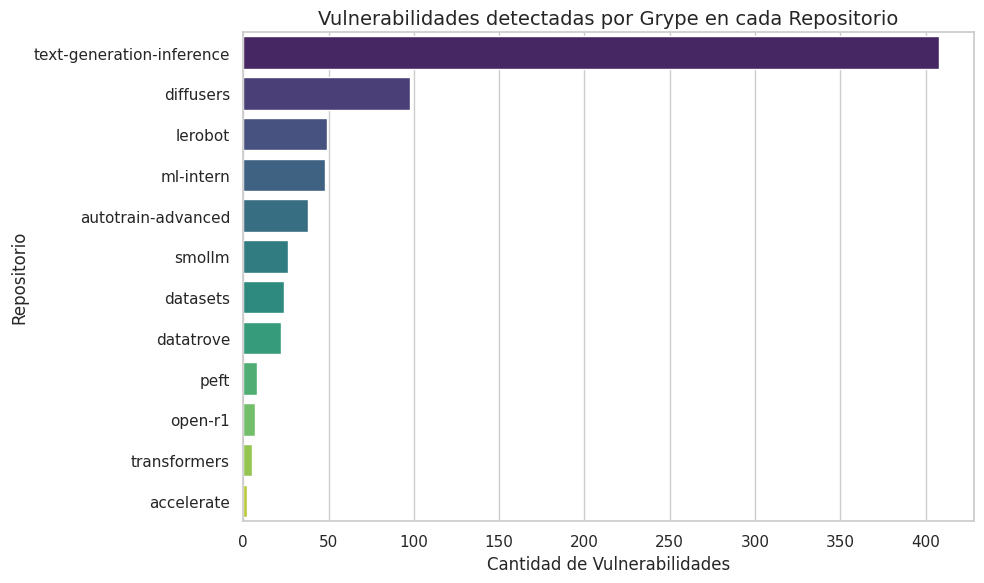

El repositorio con más vulnerabilidades detectadas por Grype es: 'text-generation-inference' con 408 detecciones.

Distribución de Severidad en los 3 Repositorios más vulnerables:


Severidad,critical,high,low,medium,Total General
Repositorio Top 3,,,,,
Total General,4,138,140,273,555
text-generation-inference,2,100,109,197,408
diffusers,2,18,17,61,98
lerobot,0,20,14,15,49


In [6]:
# Repositorio con más vulnerabilidades y Top 3

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

COL_SEVERITY = 'severity'
COL_REPO = 'repository'
COL_TOOL = 'source_tool'

if COL_TOOL in df.columns:
    df_grype = df[df[COL_TOOL].str.lower() == 'grype'].copy()
else:
    print(f"Error: La columna '{COL_TOOL}' no existe en el dataset principal (df).")
    df_grype = pd.DataFrame() 

if not df_grype.empty:
    # Contar vulnerabilidades por repositorio
    repo_counts = df_grype[COL_REPO].value_counts()
    
    # Generación del gráfico general
    plt.figure(figsize=(10, 6))
    sns.barplot(x=repo_counts.values, y=repo_counts.index, palette='viridis', hue=repo_counts.index, legend=False)
    
    plt.title('Vulnerabilidades detectadas por Grype en cada Repositorio', fontsize=14)
    plt.xlabel('Cantidad de Vulnerabilidades')
    plt.ylabel('Repositorio')
    plt.tight_layout()
    plt.show()
    
    top_repo = repo_counts.index[0]
    print(f"El repositorio con más vulnerabilidades detectadas por Grype es: '{top_repo}' con {repo_counts.iloc[0]} detecciones.\n")
    
    # Tabla de Severidad para los Top 3 Repositorios
    if COL_SEVERITY in df_grype.columns:
        top_3_repos = repo_counts.head(3).index.tolist()
        
        # Filtramos el dataset solo para esos 3 repositorios
        df_top3 = df_grype[df_grype[COL_REPO].isin(top_3_repos)]
        
        # Generamos la tabla cruzada de Repositorio vs Severidad
        tabla_top3 = pd.crosstab(
            index=df_top3[COL_REPO], 
            columns=df_top3[COL_SEVERITY].fillna('Desconocida'), 
            margins=True, 
            margins_name='Total General'
        )
        
        # Ordenamos la tabla de mayor a menor según el Total para mantener coherencia
        tabla_top3 = tabla_top3.sort_values(by='Total General', ascending=False)
        
        # Limpiamos un poco el formato visual
        tabla_top3.columns.name = 'Severidad'
        tabla_top3.index.name = 'Repositorio Top 3'
        
        print("Distribución de Severidad en los 3 Repositorios más vulnerables:")
        display(tabla_top3)
    else:
        print(f"No se pudo generar la tabla: no se encontró la columna '{COL_SEVERITY}'.")
        
else:
    print("No hay datos de Grype para graficar. Asegúrate de haber ejecutado la celda que carga 'df'.")

## 5. Análisis de Distribución de Riesgo en los 3 Repositorios mas vulnerables

Al desglosar las vulnerabilidades de los tres repositorios con mayor nivel de incidencia, se revela un panorama de riesgo que afecta directamente a apartados de producción, generación de imágenes y la nueva división de robótica de Hugging Face.

**1. `text-generation-inference`**
* **Distribución:** 2 Críticas | 100 Altas | 109 Bajas | 197 Medias | **Total: 408**
* **Relevancia del Repositorio:** Text Generation Inference es el motor principal que utiliza Hugging Face para servir LLMs en producción, impulsando servicios como la API de Inferencia y HuggingChat. 
* **Impacto:** Al ser un servidor expuesto a red que procesa peticiones externas constantemente, tener **100 vulnerabilidades de nivel Alto y 2 Críticas** representa un vector de ataque directo a la infraestructura en la nube. Las vulnerabilidades aquí podrían derivar en denegación de servicio (DoS) o filtración de datos entre sesiones de usuarios.

**2. `diffusers`**
* **Distribución:** 2 Críticas | 18 Altas | 17 Bajas | 61 Medias | **Total: 98**
* **Relevancia del Repositorio:** Es la librería estándar en el ecosistema open-source para la generación de imágenes y audio mediante modelos de difusión. Es utilizada por millones de artistas, desarrolladores y empresas.
* **Impacto:** Con casi 100 vulnerabilidades detectadas, el riesgo aquí se transfiere al usuario final. Dado que `diffusers` se instala localmente o en entornos de trabajo en la nube, las 2 vulnerabilidades críticas y 18 altas en sus dependencias probablemente exponen a los usuarios a la ejecución de código malicioso al descargar o procesar tensores manipulados.

**3. `lerobot`**
* **Distribución:** 0 Críticas | 20 Altas | 14 Bajas | 15 Medias | **Total: 49**
* **Relevancia del Repositorio:** LeRobot es una de las apuestas más recientes e innovadoras de Hugging Face, enfocada en aplicar Machine Learning a la robótica en el mundo real (control de hardware y motores mediante IA).
* **Impacto:** Aunque no presenta vulnerabilidades críticas, la presencia de **20 vulnerabilidades Altas** en un software diseñado para interactuar con hardware físico es un riesgo considerable. A medida que esta librería madure y sea adoptada en entornos industriales o académicos, estas brechas podrían permitir la manipulación de comandos físicos enviados a los robots.

In [7]:
# Distribución de Vulnerabilidades Críticas y Altas por Repositorio

import numpy as np
import pandas as pd

COL_SEVERITY = 'severity'
COL_REPO = 'repository'

if COL_SEVERITY in df.columns and COL_REPO in df.columns:
    severities = df[COL_SEVERITY].astype(str).str.lower()
    
    mask_crit = severities.isin(['critical'])
    mask_high = severities.isin(['high'])
    
    df_prioridad = df[mask_crit | mask_high].copy()
    
    if not df_prioridad.empty:
        df_prioridad['Nivel_Riesgo'] = np.where(
            df_prioridad[COL_SEVERITY].astype(str).str.lower().isin(['critical']), 
            'Críticas', 
            'Altas'
        )
        
        tabla_riesgo_repo = pd.crosstab(
            index=df_prioridad[COL_REPO], 
            columns=df_prioridad['Nivel_Riesgo']
        )
        
        if 'Críticas' not in tabla_riesgo_repo.columns: tabla_riesgo_repo['Críticas'] = 0
        if 'Altas' not in tabla_riesgo_repo.columns: tabla_riesgo_repo['Altas'] = 0
            
        tabla_riesgo_repo['Total (Críticas + Altas)'] = tabla_riesgo_repo['Críticas'] + tabla_riesgo_repo['Altas']
        tabla_riesgo_repo = tabla_riesgo_repo.sort_values(by='Total (Críticas + Altas)', ascending=False)
        
        tabla_riesgo_repo = tabla_riesgo_repo.reset_index()
        tabla_riesgo_repo.columns.name = None 
        tabla_riesgo_repo.rename(columns={COL_REPO: 'Repositorio'}, inplace=True)
        
        print("Distribución de Vulnerabilidades de Alta Prioridad por Repositorio:")
        display(tabla_riesgo_repo)
    else:
        print("No se encontraron vulnerabilidades Críticas ni Altas en el dataset.")
else:
    print(f"Error: Verifica que las columnas '{COL_SEVERITY}' y '{COL_REPO}' existan en el dataset.")

Distribución de Vulnerabilidades de Alta Prioridad por Repositorio:


,Repositorio,Altas,Críticas,Total (Críticas + Altas)
0,text-generation-inference,100,2,102
1,lerobot,20,0,20
2,diffusers,18,2,20
3,ml-intern,16,2,18
4,smollm,11,5,16
5,autotrain-advanced,12,2,14
6,datatrove,9,3,12
7,datasets,7,2,9
8,transformers,4,0,4
9,accelerate,2,0,2


## 6. Análisis de Distribución de los repositorios con mayores riesgos

Al obtener todos los repositorios que presentan las vulnerabilidades más riesgosas y compararlos con la lista de repositorios de la organización, nos percatamos de que la gran mayoría de estos corresponden a los mejor valorados de entre los más de 400 repositorios de la organización. Esto quiere decir que la mayor parte de los repositorios obtenidos tienen un gran impacto en el ecosistema informático, por lo que no deberían presentar vulnerabilidades de este calibre.

In [8]:
# Detalle Específico de Vulnerabilidades CRÍTICAS 

columnas = [
    'vulnerability_id', 
    'repository', 
    'location', 
    'description', 
    'package_name'
]

columnas_presentes = [col for col in columnas if col in df.columns]

if len(columnas_presentes) == len(columnas) and 'severity' in df.columns:
    
    # Solo vulnerabilidades críticas
    valores_criticos = ['critical']
    df_criticas = df[df['severity'].astype(str).str.lower().isin(valores_criticos)]
    
    if not df_criticas.empty:
        # Filtro de columnas 
        df_detalle = df_criticas[columnas].copy()
        
        # Eliminacion de vulnerabilidades duplicadas
        df_detalle_unico = df_detalle.drop_duplicates()
        
        # Ordenacion 
        df_detalle_unico = df_detalle_unico.sort_values(by=['repository', 'vulnerability_id'])
        
        df_detalle_unico.fillna('N/A', inplace=True)
        df_detalle_unico = df_detalle_unico.reset_index(drop=True)
        
        print(f"Detalle de Vulnerabilidades CRÍTICAS (Total de registros: {len(df_detalle_unico)})")
        display(df_detalle_unico)
        
    else:
        print("No se encontraron vulnerabilidades críticas para detallar.")
        
else:
    faltantes = set(columnas + ['severity']) - set(df.columns)
    print(f"Error: Faltan las siguientes columnas en el dataset: {faltantes}")

Detalle de Vulnerabilidades CRÍTICAS (Total de registros: 18)


,vulnerability_id,repository,location,description,package_name
0,GHSA-7p94-766c-hgjp,autotrain-advanced,/requirements.txt,NLTK has a Zip Slip Vulnerability,nltk
1,GHSA-wvwj-cvrp-7pv5,autotrain-advanced,/requirements.txt,Authlib JWS JWK Header Injection: Signature Ve...,authlib
2,GHSA-3863-2447-669p,datasets,/setup.py,transformers has a Deserialization of Untruste...,transformers
3,GHSA-53q9-r3pm-6pq6,datasets,/setup.py,PyTorch: `torch.load` with `weights_only=True`...,torch
4,GHSA-7p94-766c-hgjp,datatrove,/uv.lock,NLTK has a Zip Slip Vulnerability,nltk
5,GHSA-jx93-g359-86wm,datatrove,/uv.lock,SGLang's encoder parallel disaggregation syste...,sglang
6,GHSA-rgq9-fqf5-fv58,datatrove,/uv.lock,SGLang's multimodal generation module is vulne...,sglang
7,GHSA-53q9-r3pm-6pq6,diffusers,/examples/research_projects/realfill/requireme...,PyTorch: `torch.load` with `weights_only=True`...,torch
8,GHSA-vqfr-h8mv-ghfj,diffusers,/examples/server/requirements.txt,h11 accepts some malformed Chunked-Encoding bo...,h11
9,GHSA-r75f-5x8p-qvmc,ml-intern,/uv.lock,LiteLLM has SQL Injection in Proxy API key ver...,litellm


## 7. Modelado de Amenazas: Mapeo con MITRE ATT&CK y MITRE ATLAS

Por ultimo, para comprender el posible impacto de las vulnerabilidades descubiertas en la infraestructura y los usuarios de Hugging Face, hemos mapeado los hallazgos críticos con el framework **MITRE ATT&CK** (adversarios tradicionales).

### Caso 1: Envenenamiento de Modelos (Deserialización en `torch`)
* **Vulnerabilidad:** RCE vía deserialización de datos no confiables en PyTorch (`GHSA-53q9-r3pm-6pq6`).
* **Vector de Ataque:** Un atacante sube un modelo pre-entrenado malicioso (ej. un archivo `.pkl` o `.bin`) a un repositorio público. Cuando un investigador usa la librería `datasets` o `transformers` para cargarlo, el código malicioso se ejecuta en su máquina.
* **Mapeo MITRE ATT&CK:**
  * **Recolección (TA0009):** Tras lograr la ejecución, el atacante puede realizar **Data from Information Repositories (T1213)** para extraer modelos privados, datasets sensibles o secretos de configuración almacenados en el entorno de la víctima.
  * **Exfiltración (TA0010):** El atacante puede utilizar técnicas como **Exfiltration to Code Repository (T1567.001)** o **Exfiltration Over Web Service (T1567)** para enviar la propiedad intelectual robada a servidores externos bajo su control.
  * **Impacto (TA0040):** Se puede ejecutar una **Data Manipulation (T1491)** de tipo **Runtime Data Manipulation**, alterando el comportamiento de los modelos de IA en tiempo real para generar resultados sesgados.

### Caso 2: Ataque a la Extracción de Datasets (Zip Slip en `nltk`)
* **Vulnerabilidad:** Sobrescritura arbitraria de archivos (`GHSA-7p94-766c-hgjp`).
* **Vector de Ataque:** El atacante provee un dataset de texto comprimido maliciosamente diseñado. Al usar `nltk` dentro de repositorios como `autotrain-advanced` para descomprimirlo, el atacante puede sobrescribir archivos del sistema operativo fuera del directorio de destino pudiendo lograr la persistencia y escalar privilegios garantizando un acceso permanente y privilegiado (root) al sistema.
* **Mapeo MITRE ATT&CK:**
  * **Evasión de Defensas (TA0005):** Al tener la capacidad de sobrescribir archivos del sistema, un atacante puede realizar un **Indicator Removal (T1070)** para borrar logs de auditoría o ejecutar **Disable or Modify Tools (T1562)** para desactivar software de seguridad (antivirus, EDR) presente en el host.
  * **Ejecución (TA0002):** Puede lograrse mediante el secuestro del flujo de ejecución al sobrescribir scripts legítimos que luego son invocados por el sistema, utilizando **Command and Scripting Interpreter (T1059)** como Python o Unix Shell.
  * **Impacto (TA0040):** El atacante podría causar un **Service Stop (T1489)** al corromper binarios esenciales, provocando una denegación de servicio en las tareas de entrenamiento o despliegue de modelos.

### Caso 3: Suplantación de Identidad en APIs (Inyección en `authlib`)
* **Vulnerabilidad:** Bypass de verificación de firmas JWS/JWK (`GHSA-wvwj-cvrp-7pv5`).
* **Vector de Ataque:** En repositorios que manejan autenticación (como `autotrain-advanced`), un atacante podría manipular las cabeceras de sus tokens de sesión (JWT) para saltarse la validación criptográfica y hacerse pasar por otro usuario u obtener acceso de administrador a las consolas control.
* **Mapeo MITRE ATT&CK:**
  * **Acceso Inicial (TA0001):** La capacidad de suplantar administradores permite un **Supply Chain Compromise (T1195)**, donde el atacante inyecta código malicioso en dependencias o herramientas de desarrollo que luego serán distribuidas a miles de usuarios.
  * **Movimiento Lateral (TA0008)**: Una vez obtenida una sesión válida, el atacante puede explotar **Remote Services (T1021)** (como SSH o Cloud Services) para saltar desde el servicio de autenticación comprometido hacia otros nodos internos de la infraestructura de Hugging Face.
  * **Impacto (TA0040):** Un atacante con privilegios administrativos puede realizar un **Account Access Removal (T1531)**, eliminando las cuentas de los desarrolladores legítimos para mantener el control exclusivo sobre los repositorios afectados.

**Conclusión del Modelado de Amenazas:**
Los metodos de ataque nombrados son solo algunos de los posibles que se pueden realizar explotando algunas de las vulnerabilidades encontradas, en otras palabras, existen muchas más formas de realizar estos ataques y muchos mas exploits que no hemos revisado. Esto demuestra que, con el conocimiento necesario, el ecosistema de Hugging Face es altamente susceptible a ataques, ya que los atacantes no necesitan hackear directamente los servidores de Hugging Face; les basta con atacar sus repositorios para utilizarlos como un vector de distribución para atacar tanto a usuarios como a la organizacion misma.